In [1]:
import pandas as pd
import numpy as np

print("Pandas Version:", pd.__version__)

Pandas Version: 3.0.3


In [2]:
sdg1 = pd.read_csv("../data/SDG1_Poverty.csv")

sdg1.head()

,Country,State,Year,"Population Living Below The National Poverty Line (%) (UOM:%(Percentage)), Scaling Factor:1","Head Count Ratio As Per The Multidimensional Poverty Index (%) (UOM:%(Percentage)), Scaling Factor:1","Households With Any Usual Member Covered By A Health Scheme Or Health Insurance (%) (UOM:%(Percentage)), Scaling Factor:1","Persons Provided Employment To The Persons Who Demanded Employment Under Mahatma Gandhi National Rural Employment Guarantee Act (Mgnrega) (%) (UOM:%(Percentage)), Scaling Factor:1","Population (Out Of Total Eligible Population) Receiving Social Protection Benefits Under Pradhan Mantri Matru Vandana Yojana (Pmmvy) And Child Development (%) (UOM:%(Percentage)), Scaling Factor:1","Households Living In Katcha Houses (%) (UOM:%(Percentage)), Scaling Factor:1"
0,India,Andaman And Nicobar Islands,"Calendar Year (Jan - Dec), 2020",1.00,6.9,5.7,82.961898,96.73,0.0
1,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2020",9.20,15.6,74.6,83.808651,96.40,3.2
2,India,Arunachal Pradesh,"Calendar Year (Jan - Dec), 2020",34.67,24.4,58.3,95.435862,92.76,29.0
3,India,Assam,"Calendar Year (Jan - Dec), 2020",31.98,36.2,10.4,86.109387,95.32,2.4
4,India,Bihar,"Calendar Year (Jan - Dec), 2020",33.74,52.5,12.3,78.599921,87.97,8.2


In [3]:
print("Shape" , sdg1.shape)
sdg1.info()

Shape (36, 9)
<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 9 columns):
 #   Column                                                                                                                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                                                                                                                --------------  -----  
 0   Country                                                                                                                                                                                               36 non-null     str    
 1   State                                                                                                                                                                                                 36 non-null

In [5]:
sdg1.isnull().sum()

Country                                                                                                                                                                                                 0
State                                                                                                                                                                                                   0
Year                                                                                                                                                                                                    0
Population Living Below The National Poverty Line (%)  (UOM:%(Percentage)), Scaling Factor:1                                                                                                            1
Head Count Ratio As Per The Multidimensional Poverty Index (%) (UOM:%(Percentage)), Scaling Factor:1                                                                                            

In [6]:
sdg1.rename(columns={
    "Population Living Below The National Poverty Line (%)  (UOM:%(Percentage)), Scaling Factor:1":
    "poverty_rate",

    "Head Count Ratio As Per The Multidimensional Poverty Index (%) (UOM:%(Percentage)), Scaling Factor:1":
    "mpi_poverty",

    "Households With Any Usual Member Covered By A Health Scheme Or Health Insurance (%) (UOM:%(Percentage)), Scaling Factor:1":
    "health_insurance",

    "Persons Provided Employment To The Persons Who Demanded Employment Under Mahatma Gandhi National Rural Employment Guarantee Act (Mgnrega) (%) (UOM:%(Percentage)), Scaling Factor:1":
    "mgnrega_employment",

    "Population (Out Of Total Eligible Population) Receiving Social Protection Benefits Under Pradhan Mantri Matru Vandana Yojana (Pmmvy) And Child Development (%) (UOM:%(Percentage)), Scaling Factor:1":
    "pmmvy_coverage",

    "Households Living In Katcha Houses  (%) (UOM:%(Percentage)), Scaling Factor:1":
    "katcha_houses"
}, inplace=True)

In [7]:
sdg1.head()

,Country,State,Year,poverty_rate,mpi_poverty,health_insurance,mgnrega_employment,pmmvy_coverage,katcha_houses
0,India,Andaman And Nicobar Islands,"Calendar Year (Jan - Dec), 2020",1.00,6.9,5.7,82.961898,96.73,0.0
1,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2020",9.20,15.6,74.6,83.808651,96.40,3.2
2,India,Arunachal Pradesh,"Calendar Year (Jan - Dec), 2020",34.67,24.4,58.3,95.435862,92.76,29.0
3,India,Assam,"Calendar Year (Jan - Dec), 2020",31.98,36.2,10.4,86.109387,95.32,2.4
4,India,Bihar,"Calendar Year (Jan - Dec), 2020",33.74,52.5,12.3,78.599921,87.97,8.2


In [8]:
import os

files = os.listdir("../data")

for file in files:
    print(file)

SDG 14.csv
SDG1_Poverty.csv
SDG_10_Reduced_Inequality.csv
SDG_11_Sustainable_cities_and_communities.csv
SDG_12_Responsible_consumption_and_production.csv
SDG_13_Climate_Action.csv
SDG_15_Life_on_land.csv
SDG_16_Peace_Justice_Strong_institution.csv
SDG_2_Zero_Hunger.csv
SDG_3_Good_health_and_well_being.csv
SDG_4_Quality_Education.csv
SDG_5_Gender_Equality.csv
SDG_6_Clean_Water_and _sanitation.csv
SDG_7_Affordable and Clean Energy.csv
SDG_8_Decent_work_and_economic_growth.csv
SDG_9_Industry_and_Innovation.csv
SDG_Composite_Score.csv


In [9]:
import pandas as pd
import os

datasets = {}

for file in os.listdir("../data"):
    if file.endswith(".csv"):
        path = os.path.join("../data", file)
        datasets[file] = pd.read_csv(path)

print(f"Loaded {len(datasets)} datasets")

Loaded 17 datasets


In [10]:
summary = []

for name, df in datasets.items():
    summary.append([
        name,
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum()
    ])

summary_df = pd.DataFrame(
    summary,
    columns=[
        "Dataset",
        "Rows",
        "Columns",
        "Total Missing Values"
    ]
)

summary_df.sort_values("Dataset")

,Dataset,Rows,Columns,Total Missing Values
0,SDG 14.csv,9,8,1
1,SDG1_Poverty.csv,36,9,6
2,SDG_10_Reduced_Inequality.csv,36,10,25
3,SDG_11_Sustainable_cities_and_communities.csv,36,11,4
4,SDG_12_Responsible_consumption_and_production.csv,36,10,18
5,SDG_13_Climate_Action.csv,36,8,16
6,SDG_15_Life_on_land.csv,36,10,22
7,SDG_16_Peace_Justice_Strong_institution.csv,36,11,0
8,SDG_2_Zero_Hunger.csv,36,10,21
9,SDG_3_Good_health_and_well_being.csv,36,13,36


In [11]:
for name, df in datasets.items():
    print(
        name,
        "Duplicates:",
        df.duplicated().sum()
    )

SDG 14.csv Duplicates: 0
SDG1_Poverty.csv Duplicates: 0
SDG_10_Reduced_Inequality.csv Duplicates: 0
SDG_11_Sustainable_cities_and_communities.csv Duplicates: 0
SDG_12_Responsible_consumption_and_production.csv Duplicates: 0
SDG_13_Climate_Action.csv Duplicates: 0
SDG_15_Life_on_land.csv Duplicates: 0
SDG_16_Peace_Justice_Strong_institution.csv Duplicates: 0
SDG_2_Zero_Hunger.csv Duplicates: 0
SDG_3_Good_health_and_well_being.csv Duplicates: 0
SDG_4_Quality_Education.csv Duplicates: 0
SDG_5_Gender_Equality.csv Duplicates: 0
SDG_6_Clean_Water_and _sanitation.csv Duplicates: 0
SDG_7_Affordable and Clean Energy.csv Duplicates: 0
SDG_8_Decent_work_and_economic_growth.csv Duplicates: 0
SDG_9_Industry_and_Innovation.csv Duplicates: 0
SDG_Composite_Score.csv Duplicates: 0


In [12]:
for name, df in datasets.items():
    print(
        name,
        "Unique States:",
        df["State"].nunique()
    )

SDG 14.csv Unique States: 9
SDG1_Poverty.csv Unique States: 36
SDG_10_Reduced_Inequality.csv Unique States: 36
SDG_11_Sustainable_cities_and_communities.csv Unique States: 36
SDG_12_Responsible_consumption_and_production.csv Unique States: 36
SDG_13_Climate_Action.csv Unique States: 36
SDG_15_Life_on_land.csv Unique States: 36
SDG_16_Peace_Justice_Strong_institution.csv Unique States: 36
SDG_2_Zero_Hunger.csv Unique States: 36
SDG_3_Good_health_and_well_being.csv Unique States: 36
SDG_4_Quality_Education.csv Unique States: 36
SDG_5_Gender_Equality.csv Unique States: 36
SDG_6_Clean_Water_and _sanitation.csv Unique States: 36
SDG_7_Affordable and Clean Energy.csv Unique States: 36
SDG_8_Decent_work_and_economic_growth.csv Unique States: 36
SDG_9_Industry_and_Innovation.csv Unique States: 36
SDG_Composite_Score.csv Unique States: 36


In [13]:
sdg3 = datasets["SDG_3_Good_health_and_well_being.csv"]

sdg3.isnull().sum()

Country                                                                                                                                                          0
State                                                                                                                                                            0
Year                                                                                                                                                             0
Maternal Mortality Ratio Per 1,00,000 Live Births (UOM:PerLakh(100000)), Scaling Factor:1                                                                       17
Mortality Rate Per 1,000 Live Births Under 5 Years Of Age (UOM:Number), Scaling Factor:1                                                                        13
Fully Immunized Children In The Age Group Of 9 To 11 Months (%) (UOM:%(Percentage)), Scaling Factor:1                                                            0
Notification Rate Of T

In [31]:
import re

def clean_column_name(col):

    col = col.lower()

    # remove entire scaling factor text
    col = re.sub(r',?\s*scaling factor:\d+', '', col)

    # remove UOM section
    col = re.sub(r'\(uom:.*?\)', '', col)

    # remove remaining brackets
    col = re.sub(r'[\(\)]', '', col)

    # replace % with percent
    col = col.replace('%', 'percent')

    # keep only letters/numbers/underscore
    col = re.sub(r'[^a-z0-9]+', '_', col)

    # remove duplicate underscores
    col = re.sub(r'_+', '_', col)

    # remove leading/trailing underscores
    col = col.strip('_')

    return col

In [32]:
datasets = {}

for file in os.listdir("../data"):
    if file.endswith(".csv"):
        datasets[file] = pd.read_csv(
            os.path.join("../data", file)
        )

In [33]:
for name, df in datasets.items():
    df.columns = [clean_column_name(col) for col in df.columns]

In [34]:
datasets["SDG1_Poverty.csv"].columns

Index(['country', 'state', 'year',
       'population_living_below_the_national_poverty_line_percent',
       'head_count_ratio_as_per_the_multidimensional_poverty_index_percent',
       'households_with_any_usual_member_covered_by_a_health_scheme_or_health_insurance_percent',
       'persons_provided_employment_to_the_persons_who_demanded_employment_under_mahatma_gandhi_national_rural_employment_guarantee_act_mgnrega_percent',
       'population_out_of_total_eligible_population_receiving_social_protection_benefits_under_pradhan_mantri_matru_vandana_yojana_pmmvy_and_child_development_percent',
       'households_living_in_katcha_houses_percent'],
      dtype='str')

In [36]:
datasets["SDG_2_Zero_Hunger.csv"].columns

Index(['country', 'state', 'year',
       'beneficiaries_covered_under_national_food_security_act_nfsa_2013_percent',
       'children_who_are_underweight_under_five_years_of_age_percent',
       'children_who_are_stunned_under_five_years_of_age_percent',
       'anaemic_pregnant_women_in_the_age_group_of_15_to_49_years_percent',
       'anaemic_adolescents_in_the_age_group_of_10_to_19_years_percent',
       'rice_and_wheat_produced_annually_per_unit_area_directorate_of_economics_and_statistics_2018_19',
       'gross_value_added_constant_prices_in_agriculture_per_worker'],
      dtype='str')

In [38]:
for name, df in datasets.items():

    dup_cols = df.columns[df.columns.duplicated()]

    if len(dup_cols) > 0:
        print(name)
        print(list(dup_cols))

In [40]:
datasets["SDG 14.csv"].columns

Index(['country', 'state', 'year',
       'mean_shore_zone_coastal_water_quality_biochemical_oxygen_demand_bod',
       'mean_shore_zone_coastal_water_quality_total_nitrogen_tn',
       'increase_in_area_under_mangroves_percent',
       'average_marine_acidity_ph_measured_at_representative_sampling_stations_in_the_shore_zone',
       'potential_area_available_for_developed_under_aquaculture_percent'],
      dtype='str')

In [ ]:
for name, df in datasets.items(): # drop country col from each dtaset
    if "country" in df.columns:
        datasets[name] = df.drop(columns=["country"])

In [42]:
datasets["SDG1_Poverty.csv"].head()

,state,year,population_living_below_the_national_poverty_line_percent,head_count_ratio_as_per_the_multidimensional_poverty_index_percent,households_with_any_usual_member_covered_by_a_health_scheme_or_health_insurance_percent,persons_provided_employment_to_the_persons_who_demanded_employment_under_mahatma_gandhi_national_rural_employment_guarantee_act_mgnrega_percent,population_out_of_total_eligible_population_receiving_social_protection_benefits_under_pradhan_mantri_matru_vandana_yojana_pmmvy_and_child_development_percent,households_living_in_katcha_houses_percent
0,Andaman And Nicobar Islands,"Calendar Year (Jan - Dec), 2020",1.00,6.9,5.7,82.961898,96.73,0.0
1,Andhra Pradesh,"Calendar Year (Jan - Dec), 2020",9.20,15.6,74.6,83.808651,96.40,3.2
2,Arunachal Pradesh,"Calendar Year (Jan - Dec), 2020",34.67,24.4,58.3,95.435862,92.76,29.0
3,Assam,"Calendar Year (Jan - Dec), 2020",31.98,36.2,10.4,86.109387,95.32,2.4
4,Bihar,"Calendar Year (Jan - Dec), 2020",33.74,52.5,12.3,78.599921,87.97,8.2


In [43]:
master = datasets["SDG_Composite_Score.csv"].copy()

In [44]:
print("Master Dataset Shape:", master.shape)

Master Dataset Shape: (36, 18)


In [45]:
for name, df in datasets.items():

    if name != "SDG_Composite_Score.csv":

        master = master.merge(
            df,
            on=["state", "year"],
            how="left"
        )

In [46]:
print(master.shape)

(36, 134)


In [47]:
master.head()

,state,year,sdg_india_index_no_poverty,sdg_india_index_zero_hunger,sdg_india_index_good_health_and_well_being,sdg_india_index_quality_education,sdg_india_index_gender_equality,sdg_india_index_clean_water_and_sanitation,sdg_india_index_affordable_and_clean_energy,sdg_india_index_decent_work_and_economic_growth,...,functioning_branches_of_commercial_banks_per_1_00_000_population,automated_teller_machines_atms_per_1_00_000_population,women_account_holders_under_pradhan_mantri_jan_dhan_yojana_pmjdy_percent,targeted_habitations_connected_by_all_weather_roads_under_pradhan_mantri_gram_sadak_yojana_pmgsy,share_of_gross_value_added_gva_in_manufacturing_to_total_gross_value_added_gva_in_current_prices_percent,manufacturing_employment_as_a_percentage_of_total_employment_percent,innovation_score_as_per_the_india_innovation_index,score_as_per_logistics_ease_across_different_states_leads_report,mobile_connections_per_100_persons_mobile_tele_density_as_per_deptof_telecommunications,internet_subscribers_per_100_population_as_per_deptof_telecommunications
0,Andaman And Nicobar Islands,"Calendar Year (Jan - Dec), 2020",71,45,68,57,68,87,100,59,...,18.796992,29.824561,47.94,0.000000,1.089261,7.19,18.89,NaN,87.87,NaN
1,Andhra Pradesh,"Calendar Year (Jan - Dec), 2020",81,52,77,50,58,92,100,67,...,14.397612,21.008004,59.31,98.460292,9.580831,10.60,24.19,3.42,85.71,65.61
2,Arunachal Pradesh,"Calendar Year (Jan - Dec), 2020",54,66,64,41,37,67,85,50,...,11.826544,16.360053,55.05,81.747270,3.200942,2.05,14.90,2.77,84.00,52.34
3,Assam,"Calendar Year (Jan - Dec), 2020",51,41,59,43,25,64,98,50,...,8.892593,11.600034,59.26,94.376955,12.252417,10.55,16.38,3.00,67.51,41.57
4,Bihar,"Calendar Year (Jan - Dec), 2020",32,31,66,29,48,91,78,50,...,6.372698,6.841954,56.22,97.182163,7.213315,5.30,14.48,2.85,50.65,30.99


In [48]:
master["state"].nunique()

36

In [49]:
master.isnull().sum().sort_values(
    ascending=False
).head(20)

mean_shore_zone_coastal_water_quality_total_nitrogen_tn                                                                    28
increase_in_area_under_mangroves_percent                                                                                   27
mean_shore_zone_coastal_water_quality_biochemical_oxygen_demand_bod                                                        27
average_marine_acidity_ph_measured_at_representative_sampling_stations_in_the_shore_zone                                   27
potential_area_available_for_developed_under_aquaculture_percent                                                           27
maternal_mortality_ratio_per_1_00_000_live_births                                                                          17
mortality_rate_per_1_000_live_births_under_5_years_of_age                                                                  13
sex_ratio_at_birth                                                                                                    

In [50]:
master.to_csv(
    "../output/SDG_Master.csv",
    index=False
)

print("Master dataset saved!")

Master dataset saved!


In [51]:
master.columns[:20]

Index(['state', 'year', 'sdg_india_index_no_poverty',
       'sdg_india_index_zero_hunger',
       'sdg_india_index_good_health_and_well_being',
       'sdg_india_index_quality_education', 'sdg_india_index_gender_equality',
       'sdg_india_index_clean_water_and_sanitation',
       'sdg_india_index_affordable_and_clean_energy',
       'sdg_india_index_decent_work_and_economic_growth',
       'sdg_india_index_industry_innovation_and_infrastructure',
       'sdg_india_index_reduced_inequality',
       'sdg_india_index_sustainable_cities_and_communities',
       'sdg_india_index_responsible_consumption_and_production',
       'sdg_india_index_climate_action', 'sdg_india_index_life_on_land',
       'sdg_india_index_peace_justice_and_strong_institutions',
       'composite_score_of_sdg_india_index',
       'mean_shore_zone_coastal_water_quality_biochemical_oxygen_demand_bod',
       'mean_shore_zone_coastal_water_quality_total_nitrogen_tn'],
      dtype='str')

In [52]:
master.to_csv(
    "../output/SDG_Master.csv",
    index=False
)

In [53]:
master.to_excel(
    "../output/SDG_Master.xlsx",
    index=False
)

In [54]:
master["composite_score_of_sdg_india_index"].describe()

count    36.000000
mean     66.055556
std       5.980657
min      52.000000
25%      61.000000
50%      67.000000
75%      70.250000
max      79.000000
Name: composite_score_of_sdg_india_index, dtype: float64

In [ ]:
master[
    ["state",
     "composite_score_of_sdg_india_index"] # top 10 states by composite score
].sort_values(
    by="composite_score_of_sdg_india_index",
    ascending=False
).head(10)

,state,composite_score_of_sdg_india_index
5,Chandigarh,79
15,Kerala,75
29,Tamil Nadu,74
11,Himachal Pradesh,74
14,Karnataka,72
8,Goa,72
34,Uttarakhand,72
1,Andhra Pradesh,72
28,Sikkim,71
19,Maharashtra,70


In [ ]:
#bottom 10 states by composite score
master[
    ["state",
     "composite_score_of_sdg_india_index"] 
].sort_values(
    by="composite_score_of_sdg_india_index",
    ascending=True
).head(10)

,state,composite_score_of_sdg_india_index
4,Bihar,52
13,Jharkhand,56
3,Assam,57
2,Arunachal Pradesh,60
27,Rajasthan,60
21,Meghalaya,60
33,Uttar Pradesh,60
6,Chhattisgarh,61
23,Nagaland,61
24,Odisha,61


In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


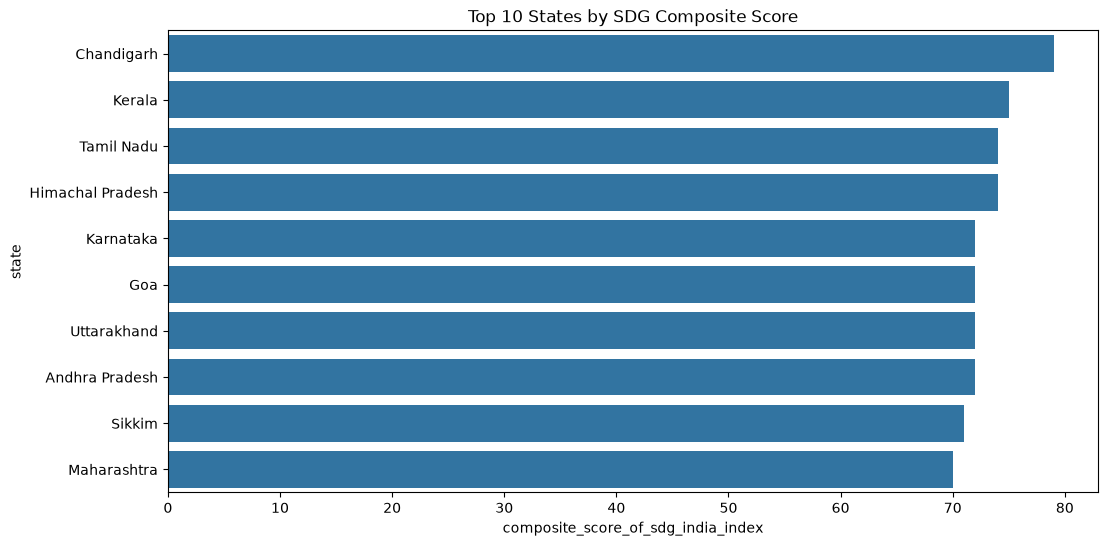

In [58]:
top10 = master[
    ["state",
     "composite_score_of_sdg_india_index"]
].sort_values(
    by="composite_score_of_sdg_india_index",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="composite_score_of_sdg_india_index",
    y="state"
)

plt.title("Top 10 States by SDG Composite Score")
plt.show()

In [59]:
# Find which drives composite score the most - correlation of top 10 features with composite score
corr = master.select_dtypes(include="number").corr()

composite_corr = corr[
    "composite_score_of_sdg_india_index"
].sort_values(
    ascending=False
)

composite_corr.head(20)

composite_score_of_sdg_india_index                                                                    1.000000
sdg_india_index_quality_education                                                                     0.808011
sdg_india_index_no_poverty                                                                            0.762355
gross_enrolment_ratio_ger_in_higher_secondary_for_classes_11_to_12                                    0.740495
functioning_branches_of_commercial_banks_per_1_00_000_population                                      0.705841
sdg_india_index_zero_hunger                                                                           0.675381
gross_enrolment_ratio_ger_in_higher_education_in_the_age_group_of_18_to_23_years                      0.673396
mobile_connections_per_100_persons_mobile_tele_density_as_per_deptof_telecommunications               0.669551
sdg_india_index_decent_work_and_economic_growth                                                       0.662979
s

In [60]:
composite_corr.tail(20)

anaemic_pregnant_women_in_the_age_group_of_15_to_49_years_percent                                     -0.300739
scheduled_caste_sc_or_scheduled_tribe_st_seats_in_state_legislative_assemblies_percent                -0.325691
murders_per_1_00_000_population                                                                       -0.384732
children_who_are_underweight_under_five_years_of_age_percent                                          -0.402307
disability_adjusted_life_years_daly_rate_attributable_to_air_pollution_per_1_00_000_population        -0.406855
increase_in_area_under_mangroves_percent                                                              -0.422655
households_living_in_katcha_houses_percent                                                            -0.435952
anaemic_adolescents_in_the_age_group_of_10_to_19_years_percent                                        -0.461262
pupil_teacher_ratio_ptr_at_secondary_level_for_classes_9_to_10                                        -0

In [ ]:
# which sdg is in general doing better - average score of each sdg across states
sdg_cols = [col for col in master.columns if col.startswith("sdg_india_index")] 

master[sdg_cols].mean().sort_values()

sdg_india_index_industry_innovation_and_infrastructure    48.138889
sdg_india_index_gender_equality                           50.111111
sdg_india_index_climate_action                            53.277778
sdg_india_index_zero_hunger                               55.472222
sdg_india_index_quality_education                         57.111111
sdg_india_index_decent_work_and_economic_growth           59.833333
sdg_india_index_life_on_land                              64.527778
sdg_india_index_no_poverty                                66.500000
sdg_india_index_reduced_inequality                        67.527778
sdg_india_index_good_health_and_well_being                71.805556
sdg_india_index_sustainable_cities_and_communities        72.222222
sdg_india_index_peace_justice_and_strong_institutions     72.583333
sdg_india_index_responsible_consumption_and_production    74.333333
sdg_india_index_clean_water_and_sanitation                84.555556
sdg_india_index_affordable_and_clean_energy     

In [ ]:
# Which SDG has the highest inequality between states?
# we are finding standard deviation which tells how much sdg scores vary between states - higher std means more inequality
sdg_cols = [col for col in master.columns if col.startswith("sdg_india_index")]

master[sdg_cols].std().sort_values(ascending=False)

sdg_india_index_zero_hunger                               16.538243
sdg_india_index_climate_action                            15.331780
sdg_india_index_industry_innovation_and_infrastructure    14.552668
sdg_india_index_no_poverty                                14.456832
sdg_india_index_sustainable_cities_and_communities        14.178678
sdg_india_index_life_on_land                              13.635010
sdg_india_index_responsible_consumption_and_production    12.897397
sdg_india_index_affordable_and_clean_energy               12.125534
sdg_india_index_quality_education                         12.101423
sdg_india_index_reduced_inequality                        11.596763
sdg_india_index_clean_water_and_sanitation                10.656841
sdg_india_index_gender_equality                            9.662232
sdg_india_index_decent_work_and_economic_growth            9.060117
sdg_india_index_peace_justice_and_strong_institutions      7.969137
sdg_india_index_good_health_and_well_being      